Maybe try to read in the opera datasets into MintPy for improved time series velocities and ascending/descending decomposition? Then clip the datasets by the aquifers for zonal statistics?

In [ ]:
# TODO: REWRITE THE INSAR DECOMPOSER CLASS WITH UPDATED CODE

In [77]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from mintpy import view, tsview
import os, shutil
from pathlib import Path
import geopandas as gpd
from transboundary_opera.decomposer import InSARDecomposer
import transboundary_opera.decomposition_tools as dt
import xarray as xr
from mintpy.asc_desc2horz_vert import run_asc_desc2horz_vert, get_overlap_lalo
from mintpy.utils import readfile
from argparse import Namespace
from mintpy.utils import readfile
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import cartopy.io.shapereader as shpreader


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
gdf = gpd.read_file(Path(os.getcwd()).parent.parent / "raw_data/TBA_full.shp")

aquifer = 'N015'

data_storage = Path('/home/clayc/Documents/US_Mex_InSAR') / "OPERA_data" / aquifer    # linux
# data_storage = Path('/mnt/c/Users/clayc/Documents/US_Mex_InSAR') / "OPERA_data"    # WSL
mintpy_paths = list(data_storage.glob('*/mintpy'))
opera_product_paths = list(data_storage.glob('*/subset-ncs/*.nc'))

In [ ]:
# %matplotlib widget
# import os
# from mintpy.cli import tsview

# ts_file = os.path.expanduser('~/data/test/FernandinaSenDT128/mintpy/timeseries_SET_ERA5_ramp_demErr.h5')
# cmd = f'{ts_file} --yx 220 300 --figsize 9 3 --ref-date 20141225 '
# tsview.main(cmd.split())

# Test how to find the overlapping clipped pairs

In [8]:
asc_list = []
desc_list = []

for velo_file in list(data_storage.glob('*/*/velocity.h5')):
    orb_dir = xr.open_dataset(velo_file, engine='h5netcdf', phony_dims = 'sort').attrs['ORBIT_DIRECTION']
    if orb_dir == 'Ascending':
        asc_list.append(velo_file)
    else:
        desc_list.append(velo_file)

asc_attrs = [readfile.read_attribute(str(f)) for f in asc_list]
desc_attrs = [readfile.read_attribute(str(f)) for f in desc_list]

In [ ]:
for i, asc_file in enumerate(asc_list):
    for j, desc_file in enumerate(desc_list):
        bbox = get_overlap_lalo([asc_attrs[i], desc_attrs[j]])
        S, N, W, E = bbox
        
        lat_step = float(asc_attrs[i]['Y_STEP'])
        lon_step = float(asc_attrs[i]['X_STEP'])
        length = int(round((S - N) / lat_step))
        width = int(round((E - W) / lon_step))

        if (length > 0 and width > 0):
            inps = Namespace(
                file=[asc_file, desc_file],
                geom_file=[asc_file.parent / 'geometryGeo.h5', desc_file.parent / 'geometryGeo.h5'],
                ds_name=None,
                horz_az_angle=-90.0,
                outfile=[str(data_storage / f'{asc_file.parts[-3]}_{desc_file.parts[-3]}_horizontalDefo.h5'), str(data_storage/ f'{asc_file.parts[-3]}_{desc_file.parts[-3]}_verticalDefo.h5')]          
            )

            run_asc_desc2horz_vert(inps)

Asc: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096/mintpy/velocity.h5
Desc: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/30454/mintpy/velocity.h5
SNWE: 3209310.0, 3110850.0, 370860.0, 401040.0
Computed length: -3282, width: 1006
Actual overlap: False
---
Asc: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096/mintpy/velocity.h5
Desc: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/30453/mintpy/velocity.h5
SNWE: 3209310.0, 3221490.0, 370860.0, 401610.0
Computed length: 406, width: 1025
Actual overlap: True
---
overlapping area in SNWE: (3209310.0, 3221490.0, 370860.0, 401610.0)
read  from file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096/mintpy/velocity.h5
read 2D LOS incidence / azimuth angles from file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096/mintpy/geometryGeo.h5
read  from file: /home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/30453/mintpy/velocity.h5
read 2D LOS incidence / azimuth angles from file: /home/clayc/Documents/US_Mex_

## Try to visualzie the new decomposed h5 files?

In [ ]:
horz_defo_files = list(data_storage.glob('*horizontalDefo*'))
vert_defo_files = list(data_storage.glob('*verticalDefo*'))

[PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1094_30454_verticalDefo.h5'),
 PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096_30453_verticalDefo.h5'),
 PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30453_verticalDefo.h5'),
 PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30454_verticalDefo.h5')]

In [74]:
# Before the loop, find global color limits
all_horz_vals = []
all_vert_vals = []
for hf, vf in zip(horz_defo_files, vert_defo_files):
    h = readfile.read(str(hf))[0] * 100
    v = readfile.read(str(vf))[0] * 100
    all_horz_vals.extend([np.nanmin(h), np.nanmax(h)])
    all_vert_vals.extend([np.nanmin(v), np.nanmax(v)])

horz_vlim = max(abs(min(all_horz_vals)), abs(max(all_horz_vals)))
vert_vlim = max(abs(min(all_vert_vals)), abs(max(all_vert_vals)))

In [88]:
def get_pair_name(f):
    return f.stem.replace('_horizontalDefo', '').replace('_verticalDefo', '')

horz_dict = {get_pair_name(f): f for f in horz_defo_files}
vert_dict = {get_pair_name(f): f for f in vert_defo_files}

matched_pairs = []
for pair_name in horz_dict:
    if pair_name in vert_dict:
        matched_pairs.append((pair_name, horz_dict[pair_name], vert_dict[pair_name]))
        print(f"Matched: {pair_name}")

Matched: 1095_30453
Matched: 1094_30454
Matched: 1096_30453
Matched: 1095_30454


In [90]:
matched_pairs

[('1095_30453',
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30453_horizontalDefo.h5'),
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30453_verticalDefo.h5')),
 ('1094_30454',
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1094_30454_horizontalDefo.h5'),
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1094_30454_verticalDefo.h5')),
 ('1096_30453',
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096_30453_horizontalDefo.h5'),
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1096_30453_verticalDefo.h5')),
 ('1095_30454',
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30454_horizontalDefo.h5'),
  PosixPath('/home/clayc/Documents/US_Mex_InSAR/OPERA_data/N080/1095_30454_verticalDefo.h5'))]

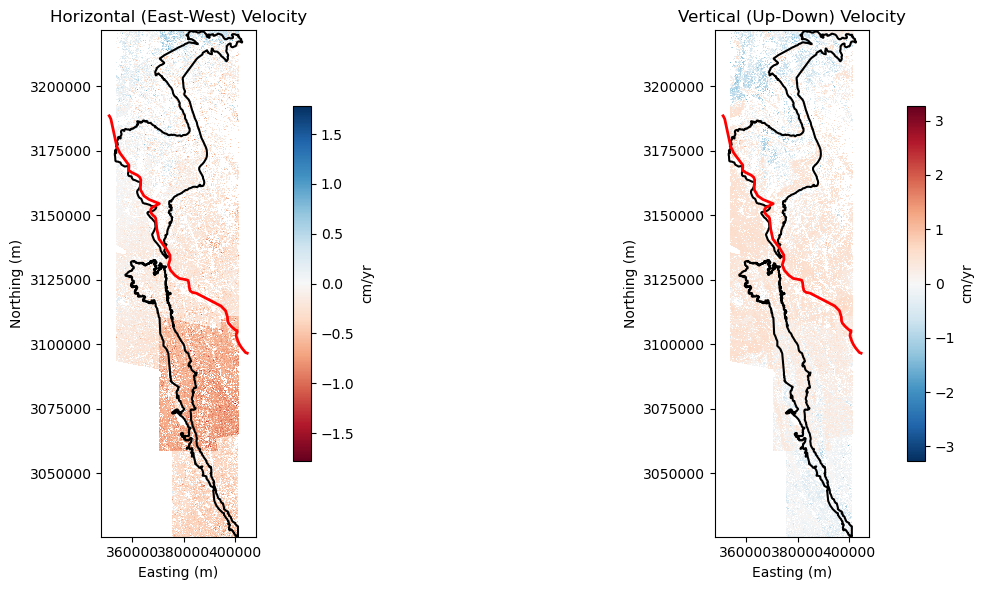

In [ ]:
# TODO: Maybe try and plot all of them in one go? Maybe not feasible, but would make a super cool plot


# Get the aquifer polygon
atr_first = readfile.read_attribute(str(horz_defo_files[0]))
raster_epsg = atr_first.get('EPSG', 'N/A')
aquifer = gdf[gdf.CODE_2021 == data_storage.stem].copy().to_crs(raster_epsg)

# Get US-Mexico border from Natural Earth
shpfile = shpreader.natural_earth(resolution='10m', category='cultural',
                                   name='admin_0_boundary_lines_land')
borders_gdf = gpd.read_file(shpfile).to_crs(raster_epsg)

# Compute global color limits
all_horz, all_vert = [], []
for hf, vf in zip(horz_defo_files, vert_defo_files):
    h = readfile.read(str(hf))[0] * 100
    v = readfile.read(str(vf))[0] * 100
    all_horz.extend([np.nanmin(h), np.nanmax(h)])
    all_vert.extend([np.nanmin(v), np.nanmax(v)])
horz_vlim = max(abs(min(all_horz)), abs(max(all_horz)))
vert_vlim = max(abs(min(all_vert)), abs(max(all_vert)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for _, horz_file, vert_file in matched_pairs:
    horz, atr_h = readfile.read(str(horz_file))
    vert, atr_v = readfile.read(str(vert_file))

    horz_cm = horz * 100
    vert_cm = vert * 100

    x0 = float(atr_h['X_FIRST'])
    xs = float(atr_h['X_STEP'])
    y0 = float(atr_h['Y_FIRST'])
    ys = float(atr_h['Y_STEP'])
    l, w = horz.shape
    extent = [x0, x0 + xs * w, y0 + ys * l, y0]

    im0 = axes[0].imshow(horz_cm, cmap='RdBu', extent=extent,
                          interpolation='nearest', vmin=-horz_vlim, vmax=horz_vlim)
    im1 = axes[1].imshow(vert_cm, cmap='RdBu_r', extent=extent,
                          interpolation='nearest', vmin=-vert_vlim, vmax=vert_vlim)

# Overlay aquifer boundary
aquifer.boundary.plot(ax=axes[0], edgecolor='black', linewidth=1.5, zorder=10)
aquifer.boundary.plot(ax=axes[1], edgecolor='black', linewidth=1.5, zorder=10)

# Overlay country borders — clip to plot extent for cleaner rendering
for ax in axes:
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    borders_gdf.clip_by_rect(xlim[0], ylim[0], xlim[1], ylim[1]).plot(
        ax=ax, edgecolor='red', linewidth=2, zorder=11
    )
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')

axes[0].set_title('Horizontal (East-West) Velocity')
axes[1].set_title('Vertical (Up-Down) Velocity')

plt.colorbar(im0, ax=axes[0], label='cm/yr', shrink=0.7)
plt.colorbar(im1, ax=axes[1], label='cm/yr', shrink=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Test other time spans for stack rebasing. Could give more granular velocites which could be related to seasonal pumping trends

# TODO: Maybe play around with other interpolation methods for getting velocity from timeseries.h5. NEED TO LOOK INTO HOW OPERA PROCESSES THIS ONE

# TODO: Figure out the best way to moasic all of the data together. Probably need GNSS data for this

## Process all identified pairs

In [ ]:
processor = InSARDecomposer(overlapping_pairs, ds_name='timeseries', angle=-90)
processor.run()
print(processor.successful_pairs)
print(processor.failed_pairs)

In [ ]:
# TODO: Make sure that we have downloaded all of the data covering the aquifers, spatially
# TODO: Exapnd the number of days we are searching

for pair in processor.successful_pairs:
    fig = dt.plot_displacements(pair['horz'], pair['vert'], time_idx=-1, gdf=gdf)

In [ ]:
# examine outputs to check
test_files = ['/home/clayc/Documents/US_Mex_InSAR/OPERA_data/16939_18905_dhorz.h5', '/home/clayc/Documents/US_Mex_InSAR/OPERA_data/16939_18905_dvert.h5']
fig = dt.plot_displacements(test_files[0], test_files[1], time_idx=-1, gdf=gdf)

## Process individual pairs and visualize them alongside intersecting aquifer boundaries

In [ ]:
pair = overlapping_pairs[2]
processor = InSARDecomposer(pair, ds_name='timeseries', azimuth=-90)

outfiles = InSARDecomposer.process_pair(processor, pair=pair)
fig = dt.plot_displacements(outfiles['horz'], outfiles['vert'], time_idx=0, gdf=gdf)